# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import random

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPool2D, Flatten, GlobalAveragePooling2D
from tensorflow.keras.applications import EfficientNetB0, DenseNet121, MobileNetV2, EfficientNetV2S
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

2024-03-22 16:30:05.565806: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-03-22 16:30:05.787663: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-22 16:30:05.787816: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-22 16:30:05.835815: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-03-22 16:30:05.952801: I tensorflow/core/platform/cpu_feature_guar

In [3]:
tf.config.experimental.list_physical_devices()

2024-03-22 16:30:31.218016: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-22 16:30:31.915812: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-22 16:30:31.915880: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2e:00.0/numa_node
Your kernel may have been built without NUMA support.


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# Disable GPU

In [4]:
tf.config.PhysicalDevice(name='GPU:0', device_type='GPU')

PhysicalDevice(name='GPU:0', device_type='GPU')

# Load Dataset

In [6]:
dataset_path = "Dataset"

imageSize = (224, 224)
batchSize = 4

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(dataset_path, "train"),
    validation_split=0.2,
    label_mode="categorical",
    subset="training",
    seed=SEED,
    image_size=imageSize,
    batch_size=batchSize
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(dataset_path, "train"),
    validation_split=0.2,
    label_mode="categorical",
    subset="validation",
    seed=SEED,
    image_size=imageSize,
    batch_size=batchSize
)


Found 3208 files belonging to 20 classes.
Using 2567 files for training.
Found 3208 files belonging to 20 classes.
Using 641 files for validation.


In [4]:
train_ds.class_names

['ABBOTTS BABBLER',
 'ABBOTTS BOOBY',
 'ABYSSINIAN GROUND HORNBILL',
 'AFRICAN CROWNED CRANE',
 'AFRICAN EMERALD CUCKOO',
 'AFRICAN FIREFINCH',
 'AFRICAN OYSTER CATCHER',
 'AFRICAN PIED HORNBILL',
 'AFRICAN PYGMY GOOSE',
 'ALBATROSS',
 'ALBERTS TOWHEE',
 'ALEXANDRINE PARAKEET',
 'ALPINE CHOUGH',
 'ALTAMIRA YELLOWTHROAT',
 'AMERICAN AVOCET',
 'AMERICAN BITTERN',
 'AMERICAN COOT',
 'AMERICAN FLAMINGO',
 'AMERICAN GOLDFINCH',
 'AMERICAN KESTREL']

tf.Tensor([0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.], shape=(20,), dtype=float32)
tf.Tensor([0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.], shape=(20,), dtype=float32)
tf.Tensor([0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.], shape=(20,), dtype=float32)
tf.Tensor([0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.], shape=(20,), dtype=float32)


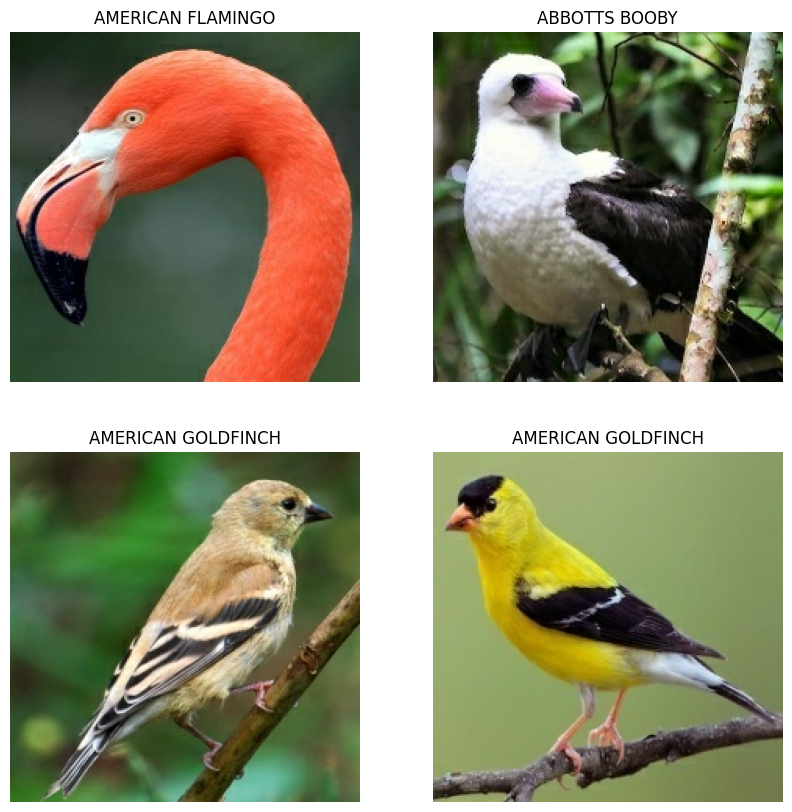

In [5]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(len(images)):
        ax = plt.subplot(2, 2, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i].numpy().argmax()])
        print(labels[i])
        plt.axis("off")

## Image Data Generator

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen_train = ImageDataGenerator(
    samplewise_center=True, # set each sample mean to 0
    rotation_range=10, # randomly rotate images in the range (degrees, 0 to 180)
    zoom_range=0.1, # Randomly zoom image
    width_shift_range=0.1, # randomly shift images horizontally (fraction of total width)
    height_shift_range=0.1, # randomly shift images vertically (fraction of total height)
    horizontal_flip=True, # randomly flip images
    vertical_flip=False,
)

datagen_val = ImageDataGenerator(samplewise_center=True)

In [8]:
# Load and iterate training dataset

train_generator = datagen_train.flow_from_directory(
    os.path.join(dataset_path, "train"),
    target_size=imageSize,
    batch_size=batchSize,
    class_mode='categorical',
    color_mode='rgb',
)

# Load and iterate validation dataset
validation_generator = datagen_val.flow_from_directory(
    os.path.join(dataset_path, "train"),
    target_size=imageSize,
    batch_size=batchSize,
    class_mode='categorical',
    color_mode='rgb',
)

Found 3208 images belonging to 20 classes.
Found 3208 images belonging to 20 classes.


In [9]:
for image, labels in train_generator:
    print(image.shape)
    print(labels.shape)
    break

(4, 224, 224, 3)
(4, 20)


# Prepare Output Directory

In [11]:
output_dir = "output/"

import time
now = time.strftime("%Y%m%d-%H%M%S", time.localtime())

model_name = now+"keras_cnn"
modelSave_dir = output_dir + model_name + "/models/"
log_dir = output_dir + model_name + "/logs/"
result_dir = output_dir + model_name + "/results/"

os.makedirs(output_dir, exist_ok=True)
os.makedirs(modelSave_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)
os.makedirs(result_dir, exist_ok=True)

# Define Callback Functions

In [12]:
def createModel (model_name):
    return ModelCheckpoint(
        modelSave_dir + model_name + ".h5",
        verbose=1,
        monitor='val_loss',
        include_optimizer=False,
        #save_best_only=True
        mode='auto'
    )
    
def createLogger (model_name):
    return CSVLogger(
        log_dir + model_name + ".csv".format(model_name),
        append=True,
        separator=','
    )
    
class custom_EarlyStopping (tf.keras.callbacks.Callback):
    def __init__(self, patience=0):
        super(custom_EarlyStopping, self).__init__()
        self.patience = patience
        # best_weights to store the weights at which the minimum loss occurs.
        self.best_weights = None
    
    def on_train_begin(self, logs=None):
        # The number of epoch it has waited when loss is no longer minimum.
        self.wait = 0
        # The epoch the training stops at.
        self.stopped_epoch = 0
        # Initialize the best as infinity.
        self.best_valLoss = np.inf
        self.best_loss = np.inf
    
    def on_epoch_end(self, epoch, logs=None):
        val_loss = logs.get('val_loss')
        loss = logs.get('loss')
        
        # if both val loss and loss does not improve for n number of patience then stop training early
        if np.less(val_loss, self.best_valLoss) and np.less(loss, self.best_loss):
            self.best_valLoss = val_loss
            self.best_loss = loss
            self.wait = 0
            # Record the best weights if current results is better (less).
            self.best_weights = self.model.get_weights()
            model.save_weights(modelSave_dir + model_name[0:10] + ".h5")
            
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.stopped_epoch = epoch
                self.model.stop_training = True
                print("Restoring model weights from the end of the best epoch.")
                self.model.set_weights(self.best_weights)
                print("Early stopping at epoch: ", self.stopped_epoch)
        
    def on_train_end(self, logs=None):
        if self.stopped_epoch > 0:
            print("Epoch %05d: early stopping" % (self.stopped_epoch + 1))
        print("Restoring model weights from the end of the best epoch.")
        self.model.set_weights(self.best_weights)
        
class timedStopping(tf.keras.callbacks.Callback):
    '''Stop training when enough time has passed.
    # Arguments
        seconds: maximum time before stopping.
        verbose: verbosity mode.
    '''
    
    def __init__(self, seconds=None, verbose=0):
        super(timedStopping, self).__init__()
        self.start_time = 0
        self.seconds = seconds
        self.verbose = verbose
        
    def on_train_begin(self, logs=None):
        self.start_time = time.time()
    
    def on_epoch_end(self, epoch, logs=None):
        if time.time() - self.start_time > self.seconds:
            self.model.stop_training = True
            if self.verbose:
                print('Stopping after %s seconds.' % self.seconds)

# Modelling

## 1st Model (No Transfer Learning CNN Model)

In [18]:
# input layer
input = Input(shape=(imageSize[0], imageSize[1], 3))

# Feature Extraction
base_model = Conv2D(filters=32, kernel_size=(3, 3), strides=1, padding='same', activation='relu')(input)
base_model = MaxPool2D(pool_size=(2, 2), strides=1)(base_model)

base_model = Conv2D(filters=64, kernel_size=(5, 5), strides=1, padding='same')(base_model)
base_model = MaxPool2D(pool_size=(2, 2), strides=1)(base_model)

base_model = Conv2D(filters=128, kernel_size=(7, 7), strides=1, padding='same', activation='relu')(base_model)
base_model = MaxPool2D(pool_size=(2, 2), strides=1)(base_model)

# Global average pooling to reduce the number of dimension
globalPool = GlobalAveragePooling2D()(base_model)

# Output layer with 2 nodes (binary classification)
dense_1 = Dense(128, activation='relu')(globalPool)
output = Dense(len(train_ds.class_names), activation='softmax')(dense_1)

model = Model(inputs=input, outputs=output)
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv2d_3 (Conv2D)           (None, 224, 224, 32)      896       
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 223, 223, 32)      0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 223, 223, 64)      51264     
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 222, 222, 64)      0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 222, 222, 128)     4015

## 2nd Model (Transfer Learning CNN Model) -> EfficientNetB0

In [13]:
# Input Layer
inputs = Input(shape=(224, 224, 3))

# Feature Extraction
base_model = EfficientNetB0(include_top=False, input_shape=(224, 224, 3), weights='imagenet')(inputs)
# Set the model to be untrainable
base_model.trainable = False

# Global average pooling to reduce the number of dimension
globalPool = GlobalAveragePooling2D()(base_model)

# Output layer with 2 nodes (binary classification)
output = Dense(len(train_ds.class_names), activation='softmax')(globalPool)

model = Model(inputs=inputs, outputs=output)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 20)                25620     
                                                                 
Total params: 4075191 (15.55 MB)
Trainable params: 4033168 (15.39 MB)
Non-trainable params: 42023 (164.16 KB)
_________________________________________________________________


### Layer of EfficientNetB0

In [14]:
model.get_layer('efficientnetb0').summary()

Model: "efficientnetb0"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 rescaling (Rescaling)       (None, 224, 224, 3)          0         ['input_2[0][0]']             
                                                                                                  
 normalization (Normalizati  (None, 224, 224, 3)          7         ['rescaling[0][0]']           
 on)                                                                                              
                                                                                                  
 rescaling_1 (Rescaling)     (None, 224, 224, 3)          0         ['normalization[0

In [15]:
model.trainable = True
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 20)                25620     
                                                                 
Total params: 4075191 (15.55 MB)
Trainable params: 4033168 (15.39 MB)
Non-trainable params: 42023 (164.16 KB)
_________________________________________________________________


### Freezing Layers (Partial Network Adoption)

In [16]:
def freeze_weight(model, backbone_name:str, unfrozen_blocks:list):
    
    layer_names = model.get_layer(backbone_name).layers
    for i in range(len(layer_names)):
        exist_flag = False
        for j in unfrozen_blocks:
            if j not in model.get_layer(backbone_name).layers[i].name and not exist_flag :
                model.get_layer(backbone_name).layers[i].trainable = False
            else :
                model.get_layer(backbone_name).layers[i].trainable = True
                exist_flag = True
    return model

In [17]:
model = freeze_weight(model, 'efficientnetb0', unfrozen_blocks=['block4', 'block5', 'block6', 'block7'])
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 20)                25620     
                                                                 
Total params: 4075191 (15.55 MB)
Trainable params: 3555278 (13.56 MB)
Non-trainable params: 519913 (1.98 MB)
_________________________________________________________________


### Regularization

In [18]:
regularizer = tf.keras.regularizers.l2(0.1)

for layer in model.layers:
    for attr in ['kernel_regularizer']:
        if hasattr(layer, attr):
            setattr(layer, attr, regularizer)


### Model Compilation

In [19]:
model.compile(optimizer=Adam(learning_rate=0.001), 
              loss='categorical_crossentropy', metrics=['accuracy'])

### Model Training

#### Keras Data Generator

In [35]:
from datetime import datetime

epochs = 10
callbacks = [
    createModel(model_name),
    createLogger(model_name),
    custom_EarlyStopping(patience=3),
#    timedStopping(seconds=3600)
]

timestamp1 = datetime.now()
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks, verbose=1)
timestamp2 = datetime.now()

print("Training time: ", timestamp2 - timestamp1)

Epoch 1/10


642/642 [==============================] - ETA: 0s - loss: 0.1192 - accuracy: 0.9610
Epoch 1: saving model to output/20240322-154742keras_cnn/models/20240322-154742keras_cnn.h5
642/642 [==============================] - 71s 110ms/step - loss: 0.1192 - accuracy: 0.9610 - val_loss: 0.2755 - val_accuracy: 0.9345
Epoch 2/10
642/642 [==============================] - ETA: 0s - loss: 0.0660 - accuracy: 0.9786
Epoch 2: saving model to output/20240322-154742keras_cnn/models/20240322-154742keras_cnn.h5
642/642 [==============================] - 74s 115ms/step - loss: 0.0660 - accuracy: 0.9786 - val_loss: 0.2316 - val_accuracy: 0.9501
Epoch 3/10
642/642 [==============================] - ETA: 0s - loss: 0.0723 - accuracy: 0.9739
Epoch 3: saving model to output/20240322-154742keras_cnn/models/20240322-154742keras_cnn.h5
642/642 [==============================] - 71s 110ms/step - loss: 0.0723 - accuracy: 0.9739 - val_loss: 0.2501 - val_accuracy: 0.9392
Epoch 4/10
642/642 [=========================

#### Image Data Generator

In [21]:
from datetime import datetime

epochs = 10
callbacks = [
    createModel(model_name),
    createLogger(model_name),
    custom_EarlyStopping(patience=3),
#    timedStopping(seconds=3600)
]

timestamp1 = datetime.now()
with tf.device('/GPU:0'):
    history = model.fit(train_generator, validation_data=validation_generator, epochs=epochs, callbacks=callbacks, verbose=1)
timestamp2 = datetime.now()

print("Training time: ", timestamp2 - timestamp1)

Epoch 1/10


2024-03-22 16:34:58.029125: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2024-03-22 16:35:01.584898: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2024-03-22 16:35:03.657798: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f723c758490 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-03-22 16:35:03.657900: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2024-03-22 16:35:03.716682: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1711100104.011562  338297 device_compiler.h:186] Compiled clus

802/802 [==============================] - ETA: 0s - loss: 1.0539 - accuracy: 0.6870
Epoch 1: saving model to output/20240322-163407keras_cnn/models/20240322-163407keras_cnn.h5


/home/wbchn/miniconda3/envs/TensorFlow-DLN/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


802/802 [==============================] - 173s 171ms/step - loss: 1.0539 - accuracy: 0.6870 - val_loss: 0.4194 - val_accuracy: 0.8747
Epoch 2/10
802/802 [==============================] - ETA: 0s - loss: 0.4794 - accuracy: 0.8557
Epoch 2: saving model to output/20240322-163407keras_cnn/models/20240322-163407keras_cnn.h5
802/802 [==============================] - 117s 145ms/step - loss: 0.4794 - accuracy: 0.8557 - val_loss: 0.2342 - val_accuracy: 0.9302
Epoch 3/10
802/802 [==============================] - ETA: 0s - loss: 0.3779 - accuracy: 0.8887
Epoch 3: saving model to output/20240322-163407keras_cnn/models/20240322-163407keras_cnn.h5
802/802 [==============================] - 126s 157ms/step - loss: 0.3779 - accuracy: 0.8887 - val_loss: 0.2706 - val_accuracy: 0.9224
Epoch 4/10
802/802 [==============================] - ETA: 0s - loss: 0.3092 - accuracy: 0.9046
Epoch 4: saving model to output/20240322-163407keras_cnn/models/20240322-163407keras_cnn.h5
802/802 [======================

### Model Evaluation

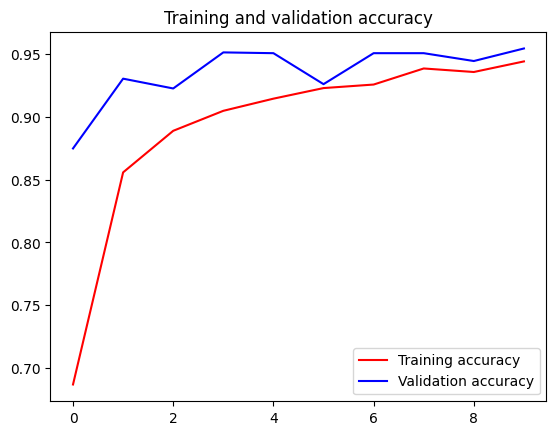

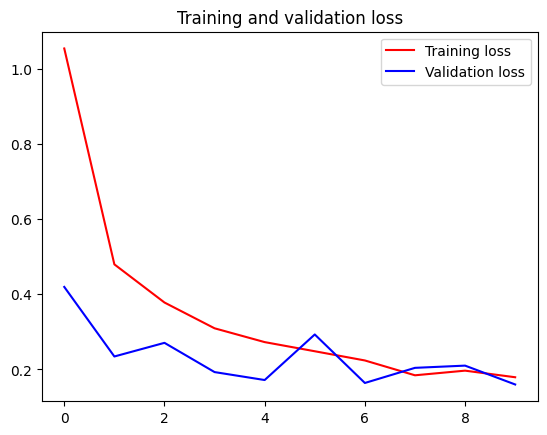

In [22]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(0, len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.savefig(result_dir + model_name + "_accuracy.png".format(model_name), dpi=100)
plt.show()

plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.savefig(result_dir + model_name + "_loss.png".format(model_name), dpi=100)
plt.show()

avg_train_acc = np.mean(acc)
avg_val_acc = np.mean(val_acc)
avg_train_loss = np.mean(loss)
avg_val_loss = np.mean(val_loss)

with(open(result_dir + model_name + "_results.txt", 'a')) as f:
    f.write("Training time: {}\n".format(timestamp2 - timestamp1))
    f.write("Average training accuracy: {}\n".format(avg_train_acc))
    f.write("Average validation accuracy: {}\n".format(avg_val_acc))
    f.write("Average training loss: {}\n".format(avg_train_loss))
    f.write("Average validation loss: {}\n".format(avg_val_loss))

### Model Testing

In [23]:
def test_model(model, test_ds):
    y_preds = []
    y = []
    for images, labels in test_ds:
        y_pred = model.predict(images)
        y.append(labels[0].numpy())
        y_preds.append(y_pred[0])
    
    cm = confusion_matrix(y_true=np.argmax(y, axis=1), y_pred=np.argmax(y_preds, axis=1))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show()
    
    return y, y_preds

In [24]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(dataset_path, "test"),
    validation_split=None,
    label_mode="categorical",
    seed=SEED,
    image_size=imageSize,
    batch_size=1
)

Found 100 files belonging to 20 classes.


1/1 [==============================] - 0s 48ms/step


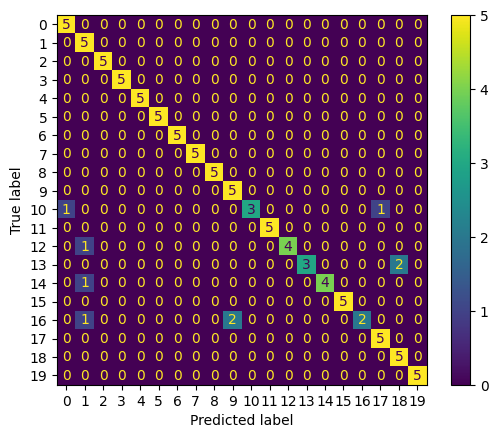

In [25]:
y, y_preds = test_model(model, test_ds)

In [26]:
model.evaluate(test_ds)

  1/100 [..............................] - ETA: 12s - loss: 0.0070 - accuracy: 1.0000

100/100 [==============================] - 3s 26ms/step - loss: 0.4348 - accuracy: 0.9100


[0.43479499220848083, 0.9100000262260437]